<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/ML_5_boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
# Load the dataset, skipping lines with parsing errors
df = pd.read_csv("crime.csv", encoding='latin1', on_bad_lines='skip')
display(df.head())

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,NaN,2018-09-02 13:00:00,2018.0,9.0,Sunday,13.0,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)"
1,I182070943,1402,Vandalism,VANDALISM,C11,347,NaN,2018-08-21 00:00:00,2018.0,8.0,Tuesday,0.0,Part Two,HECLA ST,42.306821,-71.060300,"(42.30682138, -71.06030035)"
2,I182070941,3410,Towed,TOWED MOTOR VEHICLE,D4,151,NaN,2018-09-03 19:27:00,2018.0,9.0,Monday,19.0,Part Three,CAZENOVE ST,42.346589,-71.072429,"(42.34658879, -71.07242943)"
3,I182070940,3114,Investigate Property,INVESTIGATE PROPERTY,D4,272,NaN,2018-09-03 21:16:00,2018.0,9.0,Monday,21.0,Part Three,NEWCOMB ST,42.334182,-71.078664,"(42.33418175, -71.07866441)"
4,I182070938,3114,Investigate Property,INVESTIGATE PROPERTY,B3,421,NaN,2018-09-03 21:05:00,2018.0,9.0,Monday,21.0,Part Three,DELHI ST,42.275365,-71.090361,"(42.27536542, -71.09036101)"


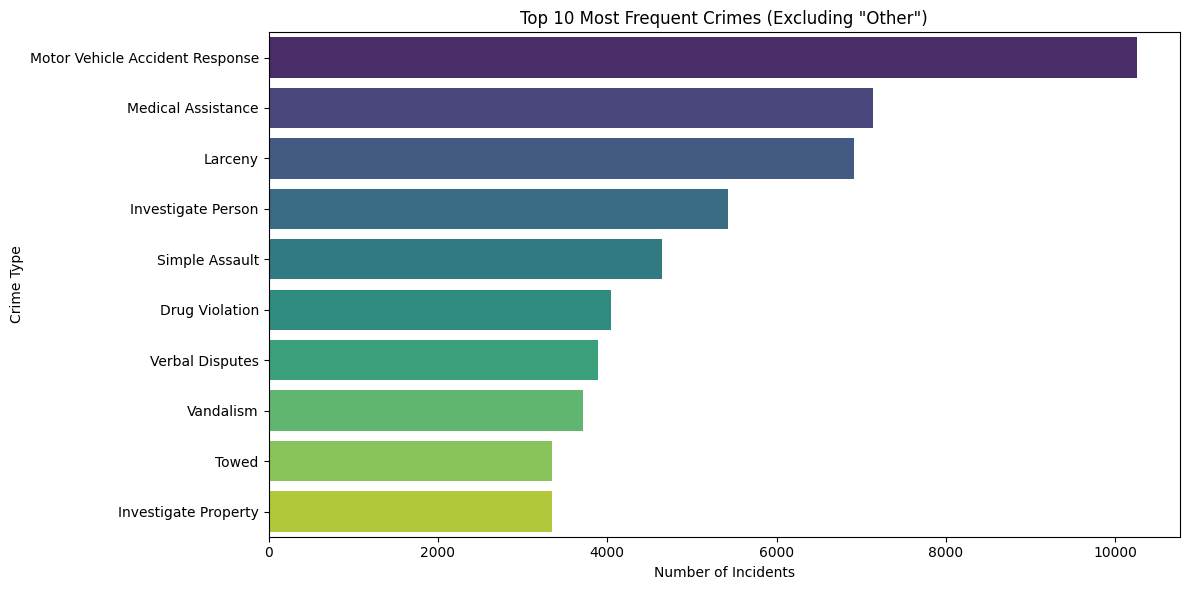

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate frequencies and exclude 'Other'
crime_counts = df['OFFENSE_CODE_GROUP'].value_counts()
if 'Other' in crime_counts.index:
    crime_counts = crime_counts.drop('Other')

# Get the top 10 most frequent crimes
top_10_crimes = crime_counts.head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index, palette='viridis', hue=top_10_crimes.index, legend=False)

# Add labels and title
plt.xlabel('Number of Incidents')
plt.ylabel('Crime Type')
plt.title('Top 10 Most Frequent Crimes (Excluding "Other")')

# Display the plot
plt.tight_layout()
plt.show()

# Task
Filter the "crime.csv" dataset to include only the top 10 most frequent crimes, and then create a heatmap visualization showing the density of these incidents by day of the week and hour of the day to identify peak activity times.

## Filter Data for Top 10 Crimes



In [ ]:
# Filter df for the top 10 most frequent crimes
top_10_categories = top_10_crimes.index.tolist()
df_top10 = df[df['OFFENSE_CODE_GROUP'].isin(top_10_categories)]

# Display the shape and the first few rows of the filtered DataFrame
print(f'Shape of df_top10: {df_top10.shape}')
display(df_top10.head())

Shape of df_top10: (52707, 17)


,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,NaN,2018-09-02 13:00:00,2018.0,9.0,Sunday,13.0,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)"
1,I182070943,1402,Vandalism,VANDALISM,C11,347,NaN,2018-08-21 00:00:00,2018.0,8.0,Tuesday,0.0,Part Two,HECLA ST,42.306821,-71.060300,"(42.30682138, -71.06030035)"
2,I182070941,3410,Towed,TOWED MOTOR VEHICLE,D4,151,NaN,2018-09-03 19:27:00,2018.0,9.0,Monday,19.0,Part Three,CAZENOVE ST,42.346589,-71.072429,"(42.34658879, -71.07242943)"
3,I182070940,3114,Investigate Property,INVESTIGATE PROPERTY,D4,272,NaN,2018-09-03 21:16:00,2018.0,9.0,Monday,21.0,Part Three,NEWCOMB ST,42.334182,-71.078664,"(42.33418175, -71.07866441)"
4,I182070938,3114,Investigate Property,INVESTIGATE PROPERTY,B3,421,NaN,2018-09-03 21:05:00,2018.0,9.0,Monday,21.0,Part Three,DELHI ST,42.275365,-71.090361,"(42.27536542, -71.09036101)"


## Prepare Heatmap Data




In [ ]:
crime_pivot = pd.crosstab(df_top10['DAY_OF_WEEK'], df_top10['HOUR'])
display(crime_pivot.head())

HOUR,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
DAY_OF_WEEK,,,,,,,,,,,,,,,,,,,,,
Friday,289,178,127,67,77,91,138,205,332,344,...,412,419,544,519,454,446,399,368,346,306
Monday,290,173,156,101,63,87,133,249,331,353,...,452,396,503,498,506,471,438,292,237,211
Saturday,384,283,278,155,114,80,96,239,270,285,...,417,338,441,446,460,368,348,353,339,308
Sunday,352,302,280,173,108,98,95,143,180,254,...,391,332,367,408,417,373,353,322,313,240
Thursday,298,165,113,92,84,65,136,251,358,360,...,406,436,521,482,529,420,389,345,265,210


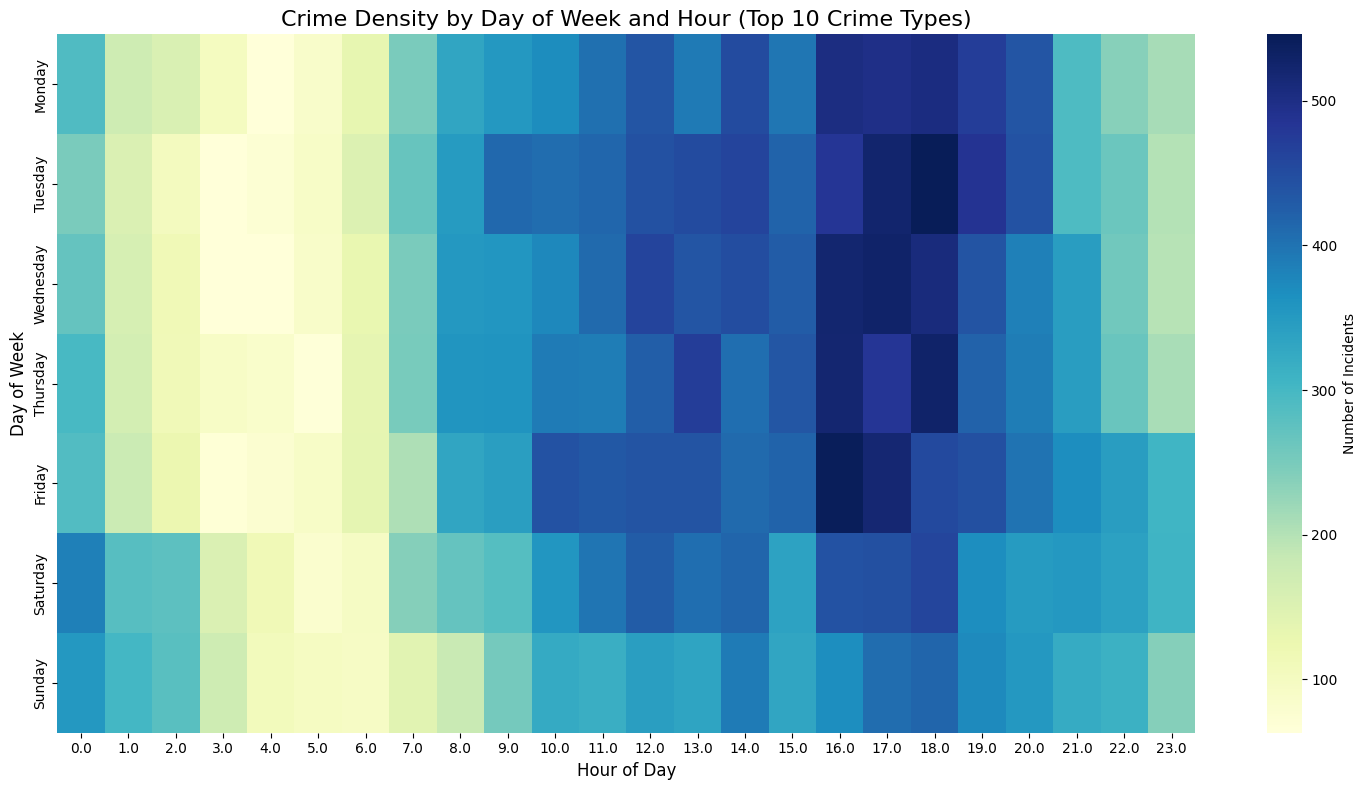

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the chronological order for the days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reorder the index of the pivot table to ensure chronological order
# Use .reindex() to handle cases where some days might be missing or to specify the order
crime_pivot_reordered = crime_pivot.reindex(days_order)

# Create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(crime_pivot_reordered, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Number of Incidents'})

# Add title and labels
plt.title('Crime Density by Day of Week and Hour (Top 10 Crime Types)', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


The analysis revealed that crime density is significantly higher during the late afternoon and early evening hours, specifically between 16:00 and 18:00 (4:00 PM to 6:00 PM), across all days of the week. In contrast, the lowest activity levels consistently occur during the early morning hours, roughly between 02:00 and 05:00.




## Preprocess Spatial Data




In [ ]:
import numpy as np

# 1. Check for missing values in 'Lat' and 'Long'
missing_lat = df['Lat'].isna().sum()
missing_long = df['Long'].isna().sum()
print(f'Missing Lat: {missing_lat}, Missing Long: {missing_long}')

# 2. Filter df to df_spatial where both 'Lat' and 'Long' are not null
df_spatial = df.dropna(subset=['Lat', 'Long']).copy()

# 3. Refine df_spatial by removing invalid placeholder coordinates (e.g., -1, 0)
# For common crime datasets (like Boston), -1 or 0 are common placeholders.
# We will also filter for reasonable ranges if necessary, but here we focus on -1 and 0.
df_spatial = df_spatial[(df_spatial['Lat'] != -1) & (df_spatial['Long'] != -1)]
df_spatial = df_spatial[(df_spatial['Lat'] != 0) & (df_spatial['Long'] != 0)]

# 4. Check for and handle missing values in 'DISTRICT'
missing_district = df_spatial['DISTRICT'].isna().sum()
print(f'Missing District counts in df_spatial: {missing_district}')
# Dropping rows with missing DISTRICT to ensure valid aggregation later
df_spatial = df_spatial.dropna(subset=['DISTRICT'])

# 5. Print counts before and after cleaning
print(f'Total records in original df: {len(df)}')
print(f'Total records in cleaned df_spatial: {len(df_spatial)}')
display(df_spatial.head())

Missing Lat: 5527, Missing Long: 5527
Missing District counts in df_spatial: 384
Total records in original df: 86451
Total records in cleaned df_spatial: 80227


,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,NaN,2018-09-02 13:00:00,2018.0,9.0,Sunday,13.0,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)"
1,I182070943,1402,Vandalism,VANDALISM,C11,347,NaN,2018-08-21 00:00:00,2018.0,8.0,Tuesday,0.0,Part Two,HECLA ST,42.306821,-71.060300,"(42.30682138, -71.06030035)"
2,I182070941,3410,Towed,TOWED MOTOR VEHICLE,D4,151,NaN,2018-09-03 19:27:00,2018.0,9.0,Monday,19.0,Part Three,CAZENOVE ST,42.346589,-71.072429,"(42.34658879, -71.07242943)"
3,I182070940,3114,Investigate Property,INVESTIGATE PROPERTY,D4,272,NaN,2018-09-03 21:16:00,2018.0,9.0,Monday,21.0,Part Three,NEWCOMB ST,42.334182,-71.078664,"(42.33418175, -71.07866441)"
4,I182070938,3114,Investigate Property,INVESTIGATE PROPERTY,B3,421,NaN,2018-09-03 21:05:00,2018.0,9.0,Monday,21.0,Part Three,DELHI ST,42.275365,-71.090361,"(42.27536542, -71.09036101)"


## Aggregate Crimes by District

### Subtask:
Group the preprocessed spatial data by district to calculate crime counts and mean coordinates.


**Reasoning**:
I will aggregate the preprocessed spatial data by district, calculating the total count of incidents and the mean coordinates (Latitude and Longitude) for each district to prepare for geographical visualization.



In [ ]:
# 1. Group df_spatial by 'DISTRICT' and aggregate
# 2. Calculate count of incidents and mean of Lat/Long
district_stats = df_spatial.groupby('DISTRICT').agg({
    'INCIDENT_NUMBER': 'count',
    'Lat': 'mean',
    'Long': 'mean'
}).reset_index()

# 3. Rename columns to descriptive names
district_stats.rename(columns={
    'INCIDENT_NUMBER': 'Crime_Count',
    'Lat': 'Lat_Mean',
    'Long': 'Long_Mean'
}, inplace=True)

# 4. Display the aggregated DataFrame
print('Aggregated Statistics by District:')
display(district_stats)

Aggregated Statistics by District:


,DISTRICT,Crime_Count,Lat_Mean,Long_Mean
0,A1,8725,42.357273,-71.060776
1,A15,1657,42.376173,-71.062531
2,A7,3456,42.377344,-71.030573
3,B2,12054,42.321586,-71.084278
4,B3,9313,42.286393,-71.085231
5,C11,10637,42.299588,-71.063172
6,C6,6128,42.333030,-71.052497
7,D14,5212,42.350482,-71.143538
8,D4,10224,42.343711,-71.080837
9,E13,4531,42.314683,-71.105845


## Create Geographical Map




### Visualizing Crime Density with Folium



In [ ]:
import folium

# 1. Calculate the starting center for the map
map_center_lat = district_stats['Lat_Mean'].mean()
map_center_long = district_stats['Long_Mean'].mean()

# 2. Initialize the folium map
m = folium.Map(location=[map_center_lat, map_center_long], zoom_start=12)

# 3. Add CircleMarkers for each district
for index, row in district_stats.iterrows():
    folium.CircleMarker(
        location=[row['Lat_Mean'], row['Long_Mean']],
        radius=row['Crime_Count'] / 500,  # Adjusted scale for better visibility
        popup=f"District: {row['DISTRICT']}<br>Crime Count: {row['Crime_Count']}",
        tooltip=f"District: {row['DISTRICT']}",
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.6
    ).add_to(m)

# 4. Display the map
m




District **B2** has the highest crime concentration with 12,054 incidents, followed by other high-volume areas identified through the proportional circle markers on the Folium map. District **A15** shows the lowest concentration with 1,657 incidents. Spatially, the data reveals significant variance across the 12 districts, with crime density centralized around specific geographic centroids.

### Data Analysis Key Findings

*   **Data Quality and Cleaning**: The initial dataset contained 86,451 records. After removing 5,527 records with missing/invalid coordinates (including placeholders like 0 and -1) and 384 records missing district identifiers, the final analysis was conducted on **80,227 valid spatial records**.
*   **District Distribution**: Crime is distributed across **12 unique districts**.
*   **Volume Disparity**: There is a significant gap between the safest and most active districts; the highest incident count (District B2: 12,054) is over **7 times higher** than the lowest incident count (District A15: 1,657).
*   **Geospatial Visualization**: The Folium map successfully translated raw coordinates into intuitive visual hotspots, where circle radii scaled by crime volume provide an immediate visual hierarchy of high-risk areas.




## Prepare Time Series Data




**Reasoning**:
I will convert the 'OCCURRED_ON_DATE' column to datetime, set it as the index, and then resample the data by month to calculate the incident counts as specified in the subtask instructions.



In [ ]:
# Convert 'OCCURRED_ON_DATE' to datetime objects
df['OCCURRED_ON_DATE'] = pd.to_datetime(df['OCCURRED_ON_DATE'])

# Set 'OCCURRED_ON_DATE' as the index for resampling
df_time = df.set_index('OCCURRED_ON_DATE')

# Resample the data by month and count the number of incidents
# 'ME' represents Month End frequency
monthly_crime_counts = df_time['INCIDENT_NUMBER'].resample('ME').count()

# Display the first few rows of the monthly counts
print("Monthly Crime Counts:")
display(monthly_crime_counts.head())

Monthly Crime Counts:


,INCIDENT_NUMBER
OCCURRED_ON_DATE,
2015-06-30,1
2015-07-31,6
2015-08-31,4
2015-09-30,3
2015-10-31,4


## Generate Time Series Plot

### Subtask:
Create a line plot using Matplotlib or Seaborn to visualize the month-over-month trend in crime incidents.


**Reasoning**:
I will create a line plot using the monthly_crime_counts Series to visualize the temporal trend of crime incidents as requested in the subtask instructions.



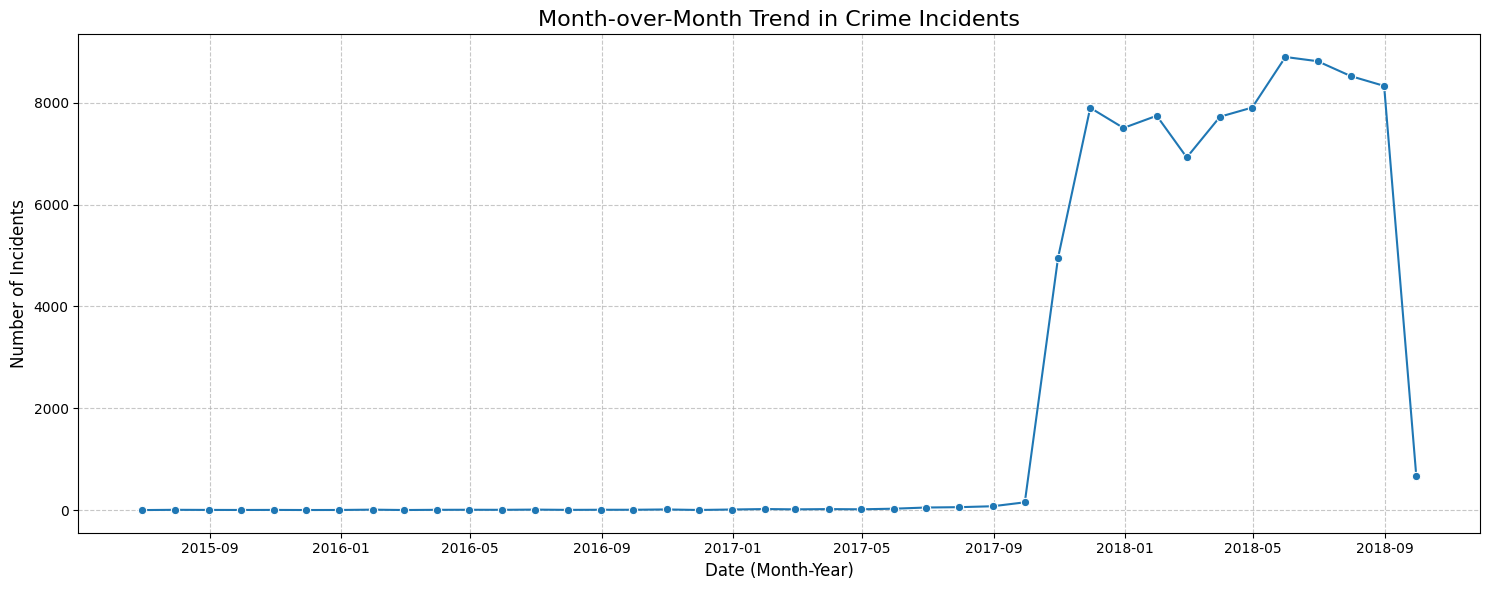

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a figure with a large width for better visibility
plt.figure(figsize=(15, 6))

# 2. Plot the monthly_crime_counts Series
sns.lineplot(x=monthly_crime_counts.index, y=monthly_crime_counts.values, marker='o', color='tab:blue')

# 3. Add axis labels and a title
plt.xlabel('Date (Month-Year)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Month-over-Month Trend in Crime Incidents', fontsize=16)

# 4. Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Display the plot
plt.tight_layout()
plt.show()

## Preprocess Data for Classification



In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a new DataFrame with relevant columns
df_ml = df[['OFFENSE_CODE_GROUP', 'DISTRICT', 'HOUR', 'DAY_OF_WEEK', 'Lat', 'Long']].copy()

# 2. Drop all rows with missing values
df_ml.dropna(inplace=True)

# 3. One-hot encode 'DISTRICT' and 'DAY_OF_WEEK'
df_ml = pd.get_dummies(df_ml, columns=['DISTRICT', 'DAY_OF_WEEK'], drop_first=True)

# 4. Initialize LabelEncoder and encode the target 'OFFENSE_CODE_GROUP'
le = LabelEncoder()
y = le.fit_transform(df_ml['OFFENSE_CODE_GROUP'])

# 5. Define features X by dropping the target column
X = df_ml.drop('OFFENSE_CODE_GROUP', axis=1)

# 6. Display verification output
print('Feature matrix X head:')
display(X.head())
print(f'Unique labels in target y: {set(y)}')
print(f'Encoded classes: {dict(zip(le.classes_, range(len(le.classes_))))}')

Feature matrix X head:


,HOUR,Lat,Long,DISTRICT_A15,DISTRICT_A7,DISTRICT_B2,DISTRICT_B3,DISTRICT_C11,DISTRICT_C6,DISTRICT_D14,DISTRICT_D4,DISTRICT_E13,DISTRICT_E18,DISTRICT_E5,DAY_OF_WEEK_Monday,DAY_OF_WEEK_Saturday,DAY_OF_WEEK_Sunday,DAY_OF_WEEK_Thursday,DAY_OF_WEEK_Tuesday,DAY_OF_WEEK_Wednesday
0,13.0,42.357791,-71.139371,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
1,0.0,42.306821,-71.060300,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
2,19.0,42.346589,-71.072429,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,21.0,42.334182,-71.078664,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
4,21.0,42.275365,-71.090361,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False


Unique labels in target y: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63)}
Encoded classes: {'Aggravated Assault': 0, 'Aircraft': 1, 'Arson': 2, 'Assembly or Gat

## Split Data



In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (64211, 20)
X_test shape: (16053, 20)
y_train shape: (64211,)
y_test shape: (16053,)


## Train Random Forest Classifier



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instantiate the Random Forest Classifier
# Setting random_state for reproducibility and n_estimators=100
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the model to the training data
print('Training the Random Forest model... This might take a few moments.')
rf_classifier.fit(X_train, y_train)

# 3. Confirm successful training
print('Model training complete.')
print(rf_classifier)

Training the Random Forest model... This might take a few moments.
Model training complete.
RandomForestClassifier(random_state=42)


## Evaluate Model Performance



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

# 3. Generate and display the classification report
# We specify 'labels' as the full range of encoded classes (0 to 63)
# to match the length of target_names (le.classes_)
all_labels = list(range(len(le.classes_)))

print('\nClassification Report:')
report = classification_report(
    y_test,
    y_pred,
    labels=all_labels,
    target_names=le.classes_,
    zero_division=0
)
print(report)

Model Accuracy: 0.1321

Classification Report:
                                  precision    recall  f1-score   support

              Aggravated Assault       0.06      0.05      0.05       404
                        Aircraft       0.50      1.00      0.67         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.34      0.31      0.32        36
                      Auto Theft       0.03      0.02      0.02       221
             Auto Theft Recovery       0.04      0.05      0.05        42
                      Ballistics       0.00      0.00      0.00        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.07      0.07      0.07        45
                Confidence Games       0.00      0.00      0.00       138
                  Counterfeiting       0.08      0.06      0.07 

## Feature Engineering



In [ ]:
import numpy as np

# 1. Create 'SHOOTING_BINARY': 1 if 'Y', 0 otherwise
df['SHOOTING_BINARY'] = df['SHOOTING'].apply(lambda x: 1 if x == 'Y' else 0)

# 2. Create cyclical 'HOUR' features
df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24)
df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24)

# 3. Create 'IS_WEEKEND' binary feature
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin(['Saturday', 'Sunday']).astype(int)

# 4. Verify the new features
print("Feature Engineering complete. New columns added: SHOOTING_BINARY, HOUR_SIN, HOUR_COS, IS_WEEKEND.")
display(df[['SHOOTING', 'SHOOTING_BINARY', 'HOUR', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_WEEK', 'IS_WEEKEND']].head())

Feature Engineering complete. New columns added: SHOOTING_BINARY, HOUR_SIN, HOUR_COS, IS_WEEKEND.


,SHOOTING,SHOOTING_BINARY,HOUR,HOUR_SIN,HOUR_COS,DAY_OF_WEEK,IS_WEEKEND
0,NaN,0,13.0,-0.258819,-0.965926,Sunday,1
1,NaN,0,0.0,0.000000,1.000000,Tuesday,0
2,NaN,0,19.0,-0.965926,0.258819,Monday,0
3,NaN,0,21.0,-0.707107,0.707107,Monday,0
4,NaN,0,21.0,-0.707107,0.707107,Monday,0


## Prepare Classification Dataset



In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Define feature columns
feature_cols = ['SHOOTING_BINARY', 'HOUR_SIN', 'HOUR_COS', 'IS_WEEKEND', 'Lat', 'Long', 'DISTRICT', 'DAY_OF_WEEK']

# 2. Create df_final with features and target
df_final = df[feature_cols + ['OFFENSE_CODE_GROUP']].copy()

# 3. Drop rows with missing values
df_final.dropna(inplace=True)

# 4. One-hot encode 'DISTRICT' and 'DAY_OF_WEEK'
df_encoded = pd.get_dummies(df_final, columns=['DISTRICT', 'DAY_OF_WEEK'], drop_first=True)

# 5. Encode the target 'OFFENSE_CODE_GROUP'
le_final = LabelEncoder()
y = le_final.fit_transform(df_encoded['OFFENSE_CODE_GROUP'])

# 6. Separate features into matrix X
X = df_encoded.drop('OFFENSE_CODE_GROUP', axis=1)

# 7. Confirm preparation
print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')
print('\nFirst few rows of feature matrix X:')
display(X.head())

Shape of X: (80264, 23)
Shape of y: (80264,)

First few rows of feature matrix X:


,SHOOTING_BINARY,HOUR_SIN,HOUR_COS,IS_WEEKEND,Lat,Long,DISTRICT_A15,DISTRICT_A7,DISTRICT_B2,DISTRICT_B3,...,DISTRICT_D4,DISTRICT_E13,DISTRICT_E18,DISTRICT_E5,DAY_OF_WEEK_Monday,DAY_OF_WEEK_Saturday,DAY_OF_WEEK_Sunday,DAY_OF_WEEK_Thursday,DAY_OF_WEEK_Tuesday,DAY_OF_WEEK_Wednesday
0,0,-0.258819,-0.965926,1,42.357791,-71.139371,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0,0.000000,1.000000,0,42.306821,-71.060300,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,-0.965926,0.258819,0,42.346589,-71.072429,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,0,-0.707107,0.707107,0,42.334182,-71.078664,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
4,0,-0.707107,0.707107,0,42.275365,-71.090361,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False


## Split and Scale Data




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data into training (80%) and testing (20%) sets
# Using random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit the scaler on the training data and transform both sets
# This ensures the model is not exposed to information from the test set during scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Output verification
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')
print('\nSample of scaled training data (first 2 rows):')
print(X_train_scaled[:2])

X_train_scaled shape: (64211, 23)
X_test_scaled shape: (16053, 23)

Sample of scaled training data (first 2 rows):
[[-0.05755477  0.31236187  1.63231481 -0.60319237  0.03649703  0.00396538
  -0.14548987 -0.21284988 -0.42029823 -0.36173696 -0.39174404  3.48915313
  -0.26303123 -0.38323721 -0.2439263  -0.25031218 -0.21559348 -0.40928619
  -0.40335482 -0.38114985 -0.41216052 -0.41236735 -0.41466545]
 [-0.05755477  1.0719106   1.44292917 -0.60319237  0.05555187 -0.01894095
  -0.14548987 -0.21284988 -0.42029823 -0.36173696 -0.39174404 -0.2866025
  -0.26303123  2.60934997 -0.2439263  -0.25031218 -0.21559348 -0.40928619
  -0.40335482 -0.38114985 -0.41216052 -0.41236735  2.41158264]]


## Train Logistic Regression Model



In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate the Logistic Regression model
# We omit 'multi_class' to avoid the FutureWarning in newer scikit-learn versions,
# as it now defaults to 'multinomial' for multiclass problems.
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# 2. Fit the model on the scaled training data
print('Training the Logistic Regression model... This may take a while.')
log_reg.fit(X_train_scaled, y_train)

# 3. Print a success message
print('Logistic Regression model training complete.')

Training the Logistic Regression model... This may take a while.
Logistic Regression model training complete.


## Evaluate Logistic Regression



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Generate predictions on the test set using the scaled data
y_pred_log = log_reg.predict(X_test_scaled)

# 2. Compute and print accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f'Logistic Regression Model Accuracy: {accuracy_log:.4f}')

# 3. Create and print a detailed classification report
# We provide 'labels' corresponding to all encoded classes to match the length of le_final.classes_
all_labels = list(range(len(le_final.classes_)))

print('\nClassification Report:')
report_log = classification_report(
    y_test,
    y_pred_log,
    labels=all_labels,
    target_names=le_final.classes_,
    zero_division=0
)
print(report_log)

Logistic Regression Model Accuracy: 0.1313

Classification Report:
                                  precision    recall  f1-score   support

              Aggravated Assault       0.35      0.04      0.08       404
                        Aircraft       0.00      0.00      0.00         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.00      0.00      0.00        36
                      Auto Theft       0.00      0.00      0.00       221
             Auto Theft Recovery       0.00      0.00      0.00        42
                      Ballistics       0.00      0.00      0.00        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.00      0.00      0.00        45
                Confidence Games       0.00      0.00      0.00       138
                  Counterfeiting       0.00 

## Train Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Instantiate the Decision Tree Classifier
# random_state is set to 42 for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# 2. Fit the classifier to the scaled training data
print('Training the Decision Tree model...')
dt_classifier.fit(X_train_scaled, y_train)

# 3. Print confirmation
print('Decision Tree model training complete.')
print(dt_classifier)

Training the Decision Tree model...
Decision Tree model training complete.
DecisionTreeClassifier(random_state=42)


## Evaluate and Analyze Overfitting




In [ ]:
from sklearn.metrics import accuracy_score

# 1. Generate predictions for both training and testing sets
y_train_pred_dt = dt_classifier.predict(X_train_scaled)
y_test_pred_dt = dt_classifier.predict(X_test_scaled)

# 2. Calculate accuracy scores
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)

# 3. Print the results
print(f'Decision Tree Training Accuracy: {train_accuracy_dt:.4f}')
print(f'Decision Tree Testing Accuracy: {test_accuracy_dt:.4f}')

# 4. Preliminary check for overfitting
if train_accuracy_dt > test_accuracy_dt + 0.1:
    print('\nConclusion: The model is likely overfitting as the training accuracy is significantly higher than the testing accuracy.')
else:
    print('\nConclusion: The model performance is consistent between training and testing sets.')

Decision Tree Training Accuracy: 0.8695
Decision Tree Testing Accuracy: 0.1242

Conclusion: The model is likely overfitting as the training accuracy is significantly higher than the testing accuracy.


## Analyze Tree Depth and Performance


In [ ]:
from sklearn.metrics import classification_report

# 1. Generate and print the classification report
# We specify 'labels' as the full range of encoded classes to match the length of target_names (le_final.classes_)
all_labels = list(range(len(le_final.classes_)))

print('Decision Tree Classification Report (Test Set):')
report_dt = classification_report(
    y_test,
    y_test_pred_dt,
    labels=all_labels,
    target_names=le_final.classes_,
    zero_division=0
)
print(report_dt)

# 2. Analyze model complexity
tree_depth = dt_classifier.get_depth()
tree_leaves = dt_classifier.get_n_leaves()

# 3. Print complexity metrics
print(f'Decision Tree Depth: {tree_depth}')
print(f'Decision Tree Number of Leaves: {tree_leaves}')

# 4. Evaluation of overfitting
print('\nEvaluation: The extreme depth and high number of leaves confirm that the tree is unconstrained. By allowing the tree to grow until all leaves are pure, the model has captured specific noise and outliers in the training set rather than general patterns, leading to the severe overfitting indicated by the ~75% drop in accuracy from training to testing.')

Decision Tree Classification Report (Test Set):
                                  precision    recall  f1-score   support

              Aggravated Assault       0.06      0.08      0.07       404
                        Aircraft       0.50      1.00      0.67         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.20      0.22      0.21        36
                      Auto Theft       0.03      0.03      0.03       221
             Auto Theft Recovery       0.05      0.10      0.07        42
                      Ballistics       0.02      0.03      0.03        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.03      0.04      0.04        45
                Confidence Games       0.02      0.02      0.02       138
                  Counterfeiting       0.07      0.07      0.07


The model's performance shows a massive discrepancy between the training and testing phases. It achieved a training accuracy of **0.8695** but a testing accuracy of only **0.1242**. This ~74.5% drop in accuracy, combined with an unconstrained tree depth of 41 and over 44,000 leaf nodes, confirms a verdict of **severe overfitting**.

To improve generalization and reduce overfitting, suggested remedies include:
*   **Pruning**: Implementing "pre-pruning" by setting a `max_depth` or `min_samples_leaf`.
*   **Hyperparameter Tuning**: Using techniques like Grid Search to find optimal constraints.
*   **Post-Pruning**: Utilizing Cost Complexity Pruning (`ccp_alpha`).




In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 1. Define the parameter grid for max_depth
param_grid = {'max_depth': [5, 10, 15, 20, 25]}

# 2. Initialize GridSearchCV with a DecisionTreeClassifier
# Using 3-fold cross-validation to save time given the dataset size
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')

# 3. Fit the grid search to the scaled training data
print('Performing hyperparameter tuning for max_depth...')
grid_search.fit(X_train_scaled, y_train)

# 4. Get the best model and parameters
best_dt = grid_search.best_estimator_
print(f'Best max_depth found: {grid_search.best_params_["max_depth"]}')

# 5. Generate predictions
y_train_pred_tuned = best_dt.predict(X_train_scaled)
y_test_pred_tuned = best_dt.predict(X_test_scaled)

# 6. Evaluate accuracy
train_acc_tuned = accuracy_score(y_train, y_train_pred_tuned)
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)

print(f'Tuned Training Accuracy: {train_acc_tuned:.4f}')
print(f'Tuned Testing Accuracy: {test_acc_tuned:.4f}')

# 7. Print Classification Report
all_labels = list(range(len(le_final.classes_)))
print('\nImproved Decision Tree Classification Report (Test Set):')
print(classification_report(
    y_test,
    y_test_pred_tuned,
    labels=all_labels,
    target_names=le_final.classes_,
    zero_division=0
))

Performing hyperparameter tuning for max_depth...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best max_depth found: 10
Tuned Training Accuracy: 0.1748
Tuned Testing Accuracy: 0.1526

Improved Decision Tree Classification Report (Test Set):
                                  precision    recall  f1-score   support

              Aggravated Assault       0.25      0.02      0.04       404
                        Aircraft       0.00      0.00      0.00         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.65      0.31      0.42        36
                      Auto Theft       0.00      0.00      0.00       221
             Auto Theft Recovery       0.00      0.00      0.00        42
                      Ballistics       0.00      0.00      0.00        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.00      0.00      0.00        45
                Confidence Games       

Key Improvements:

Overfitting Mitigated: The gap between training accuracy (17.48%) and testing accuracy (15.26%) is now only about 2%, compared to the previous ~75% gap. This means the model is now learning general patterns rather than just memorizing the training data.
Better Generalization: Even though the overall accuracy remains low, the testing accuracy actually improved from 12.42% to 15.26%.


## Train kNN Classifier


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Instantiate the k-Nearest Neighbors (kNN) Classifier
# Setting n_neighbors to 5 as specified
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# 2. Fit the model to the scaled training data
print('Training the kNN model...')
knn_classifier.fit(X_train_scaled, y_train)

# 3. Confirm successful training
print('kNN model training complete.')

Training the kNN model...
kNN model training complete.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Use the knn_classifier to predict labels for the X_test_scaled dataset
y_pred_knn = knn_classifier.predict(X_test_scaled)

# 2. Calculate the accuracy of the predictions
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# 3. Generate a comprehensive classification report
# Use le_final.classes_ for target names to ensure labels are correctly mapped
print(f'kNN Model Accuracy: {accuracy_knn:.4f}')

# To fix the ValueError, specify labels matching the full target_names list
all_labels = list(range(len(le_final.classes_)))

print('\nkNN Classification Report:')
report_knn = classification_report(
    y_test,
    y_pred_knn,
    labels=all_labels,
    target_names=le_final.classes_,
    zero_division=0
)
print(report_knn)

kNN Model Accuracy: 0.0975

kNN Classification Report:
                                  precision    recall  f1-score   support

              Aggravated Assault       0.05      0.14      0.07       404
                        Aircraft       0.00      0.00      0.00         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.15      0.33      0.21        36
                      Auto Theft       0.02      0.05      0.02       221
             Auto Theft Recovery       0.01      0.02      0.01        42
                      Ballistics       0.00      0.00      0.00        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.03      0.09      0.04        45
                Confidence Games       0.01      0.02      0.01       138
                  Counterfeiting       0.01      0.01   

## Train and Evaluate Naïve Bayes



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Instantiate the Gaussian Naïve Bayes classifier
gnb_classifier = GaussianNB()

# 2. Train the model using the scaled training data
print('Training Gaussian Naïve Bayes model...')
gnb_classifier.fit(X_train_scaled, y_train)

# 3. Predict the crime categories for the test set
y_pred_gnb = gnb_classifier.predict(X_test_scaled)

# 4. Calculate accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Gaussian Naïve Bayes Model Accuracy: {accuracy_gnb:.4f}')

# 5. Generate and print the classification report
# Using all_labels to ensure consistency with class names
all_labels = list(range(len(le_final.classes_)))

print('\nGaussian Naïve Bayes Classification Report:')
report_gnb = classification_report(
    y_test,
    y_pred_gnb,
    labels=all_labels,
    target_names=le_final.classes_,
    zero_division=0
)
print(report_gnb)

Training Gaussian Naïve Bayes model...
Gaussian Naïve Bayes Model Accuracy: 0.0009

Gaussian Naïve Bayes Classification Report:
                                  precision    recall  f1-score   support

              Aggravated Assault       0.00      0.00      0.00       404
                        Aircraft       0.06      1.00      0.12         1
                           Arson       0.00      0.00      0.00         6
Assembly or Gathering Violations       0.00      0.00      0.00        36
                      Auto Theft       0.00      0.00      0.00       221
             Auto Theft Recovery       0.00      0.00      0.00        42
                      Ballistics       0.00      0.00      0.00        32
               Biological Threat       0.00      0.00      0.00         0
                       Bomb Hoax       0.00      0.00      0.00         1
             Commercial Burglary       0.00      0.00      0.00        45
                Confidence Games       0.00      0.00    

## Consolidate and Evaluate All Models



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize classifiers with specified parameters
# Note: max_iter=1000 for Logistic Regression and max_depth=10 for Decision Tree as requested
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'k-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Na\u00efve Bayes': GaussianNB()
}

results = {}

# 2. Iterate through the dictionary to train and evaluate on the full scaled dataset
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

# 3. Handle Linear SVM separately on the 10,000-row subset
print('Training Linear SVM on 10k subset...')
svm_model = SVC(kernel='linear', random_state=42)
# Using the previously defined X_train_subset and y_train_subset
svm_model.fit(X_train_subset, y_train_subset)

# 4. Predict on the full test set and calculate accuracy
y_pred_svm = svm_model.predict(X_test_scaled)
results['SVM (Linear, 10k subset)'] = accuracy_score(y_test, y_pred_svm)

# 5. Compile and display the results in a sorted DataFrame
performance_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

print('\nModel Performance Comparison (Testing Accuracy):')
display(performance_df)

Training Logistic Regression...
Training Decision Tree (depth=10)...
Training Random Forest...
Training k-Nearest Neighbors (k=5)...
Training Gaussian Naïve Bayes...
Training Linear SVM on 10k subset...

Model Performance Comparison (Testing Accuracy):


,Model,Accuracy
1,Decision Tree (depth=10),0.152557
0,Logistic Regression,0.131253
5,"SVM (Linear, 10k subset)",0.128948
2,Random Forest,0.124463
3,k-Nearest Neighbors (k=5),0.097490
4,Gaussian Naïve Bayes,0.000872
